In [3]:
import tessutils as tu

In [2]:
from pathlib import Path

BASE = Path("C:/Users/michi/Documents/Git/data")  # gebruik / hier
BASE.mkdir(parents=True, exist_ok=True)
print(BASE)

C:\Users\michi\Documents\Git\data


In [5]:
TIC = 177162802

In [ ]:
output_dir = BASE / "processed_spb1"
tu.reduction.download_tpf(TIC, sectors=88,,outputdir=output_dir)

NameError: name 'TIC' is not defined

In [ ]:
import,astropy.units,as,u

excluded_intervals,=,{},#,Initialize,the,dictionary

excluded_intervals[1],= [ (1334.8, 1335.1)*u.day,
                          (1347.0, 1349.5)*u.day ]

excluded_intervals[3] = [ (1383.8, 1386.0)*u.day,
                        (1401.6, 1402.5)*u.day,
                        (1408, 1410)*u.day]

excluded_intervals[5] = [(1463.8, 1464.2)*u.day]

excluded_intervals[6] = [(1471.4, 1472.9)*u.day,
                         (1476.9, 1478.4)*u.day]

excluded_intervals[9] = [(1543.3, 1543.8)*u.day]

excluded_intervals[10] = [(1569.4, 1569.8)*u.day,
                          (1575.5, 1576.5)*u.day]

excluded_intervals[13] = [(1674.2, 1674.7)*u.day]

excluded_intervals[30] = [(2130.1,2130.9)*u.day]

excluded_intervals[35] = [(2266.1,2272.0)*u.day]

excluded_intervals[63] = [(3014.3,3014.5)*u.day,
                          (3014.6,3014.9)*u.day]

excluded_intervals[65] = [(3087.3,3087.5)*u.day]

excluded_intervals[68] = [(3166.6,3167.8)*u.day]

excluded_intervals[93] = [(3838.2, 3838.4)*u.day,
                          (3848.8,3849.0)*u.day,
                          (3850.0,3850.2)*u.day]

excluded_intervals[94] = [(3875.9, 3876.1)*u.day]

excluded_intervals[97] = [(3941.9, 3942.4)*u.day]

In [6]:
sectors = [1,2,3,4,5,6,7,8,9,10,11,12,13, 27,28,29,30,31,32,33,34,35,36,37,39,61,62,63,64,65,66,67,68,69,87,89,90,93,94,95,96,97]
output = BASE / "processed_spb1_better"
for sector in sectors:

    if sector >= 61:
        treshold = 1e-5
    else:
        treshold = 1e-4

    TPF_file = f'{BASE}/spb1/tic{TIC}_sec{sector}.fits' # Path to the TPF file just downloaded
    tu.reduction.extract_light_curve(TPF_file, outputdir=output, ncores=None, excluded_intervals=excluded_intervals, pc_threshold_variance=treshold)

TIC 177162802 Sector 4: No principal components (PCs) with variance>0.0001. All 7 PCs used (this is just FYI, for further information see arguments `max_num_of_pc`, `num_of_pc_bins`, `pc_threshold_variance`.
TIC 177162802 Sector 28: Skipped: Not aperture found.
TIC 177162802 Sector 29: No principal components (PCs) with variance>0.0001. All 7 PCs used (this is just FYI, for further information see arguments `max_num_of_pc`, `num_of_pc_bins`, `pc_threshold_variance`.
TIC 177162802 Sector 30: No principal components (PCs) with variance>0.0001. All 7 PCs used (this is just FYI, for further information see arguments `max_num_of_pc`, `num_of_pc_bins`, `pc_threshold_variance`.
TIC 177162802 Sector 35: No principal components (PCs) with variance>0.0001. All 7 PCs used (this is just FYI, for further information see arguments `max_num_of_pc`, `num_of_pc_bins`, `pc_threshold_variance`.
TIC 177162802 Sector 36: No principal components (PCs) with variance>0.0001. All 7 PCs used (this is just FYI, 

In [6]:
processed_pickels = BASE / "processed_year1"
group_folder = BASE / "groupped_year1"
stiched_folder = BASE / "stitched_year1"

tu.reduction.group_lcs(inputdir=processed_pickels,TICs=TIC, outputdir=group_folder)
tu.reduction.stitch_group(inputdir=group_folder,TICs=TIC, outputdir=stiched_folder)

In [7]:
group_file = BASE / "groupped_year1/tic177162802_allsectors_corrected.pickle"
pdfname=f'diagnostic_plot_TIC{TIC}.pdf'
tu.plots.plot_diagnosis(group_file, pdfname=pdfname)
print('Done.')

Reading: tic177162802_allsectors_corrected.pickle
Ploting TIC 177162802, sector 1.
Ploting TIC 177162802, sector 2.
Ploting TIC 177162802, sector 3.
Ploting TIC 177162802, sector 4.
Ploting TIC 177162802, sector 5.
Ploting TIC 177162802, sector 6.
Ploting TIC 177162802, sector 7.
Ploting TIC 177162802, sector 8.
Ploting TIC 177162802, sector 9.
Ploting TIC 177162802, sector 10.
Ploting TIC 177162802, sector 11.
Ploting TIC 177162802, sector 12.
Ploting TIC 177162802, sector 13.
Generating plot of stitched light curve and periodogram.
Saving PDF as diagnostic_plot_TIC177162802.pdf.
Done.


In [ ]:
processed_file = f'{BASE}/spbstars/cleaned/processed_spb1/tic{TIC}_sec{sector}_corrected.pickle'
pdfname=f'./spbstars/cleaned/diagnostic_plot_TIC{TIC}_sec{sector}_2.pdf'
tu.plots.plot_diagnosis(processed_file, pdfname=pdfname)

Reading: tic177162802_sec97_corrected.pickle
Ploting TIC 177162802, sector 97.
Generating plot of stitched light curve and periodogram.
Saving PDF as ./spbstars/cleaned/diagnostic_plot_TIC177162802_sec97_2.pdf.


c:\Users\michi\Documents\Git\SPB-astroseismology\tessutils\plots.py:127: UserWarning: Attempting to set identical left == right == 0.9268714726337813 results in singular transformations; automatically expanding.
  ax.set_xlim(xmin_new,xmax_new)


In [ ]:
input_dir = BASE / "processed_spb1"
output_dir = BASE / "groupped_spb1"


tu.reduction.group_lcs(inputdir=input_dir,TICs=TIC, outputdir=output_dir)

In [ ]:
input_dir = BASE / "groupped_spb1"
output_dir = BASE / "stitched_spb1"


tu.reduction.stitch_group(inputdir=input_dir,TICs=TIC, outputdir=output_dir)

Skipped: File lc_tic177162802_corrected_stitched.csv already exists.


In [8]:
import lightkurve as lk
import pandas as pd
lc = pd.read_csv(f'./spbstars/stitched_spb1/lc_tic{TIC}_corrected_stitched.csv')
lc = lk.LightCurve(time=lc.time, flux=lc.flux)

In [7]:
group_file = f'./spbstars/groupped_spb1/tic{TIC}_allsectors_corrected.pickle'
pdfname=f'diagnostic_plot_TIC{TIC}.pdf'
tu.plots.plot_diagnosis(group_file, pdfname=pdfname)
print('Done1.')

Reading: tic177162802_allsectors_corrected.pickle
Ploting TIC 177162802, sector 1.
Ploting TIC 177162802, sector 2.
Ploting TIC 177162802, sector 3.
Ploting TIC 177162802, sector 4.
Ploting TIC 177162802, sector 5.
Ploting TIC 177162802, sector 6.
Ploting TIC 177162802, sector 7.
Ploting TIC 177162802, sector 8.
Ploting TIC 177162802, sector 9.
Ploting TIC 177162802, sector 10.
Ploting TIC 177162802, sector 11.
Ploting TIC 177162802, sector 12.
Ploting TIC 177162802, sector 13.
Ploting TIC 177162802, sector 27.
Ploting TIC 177162802, sector 28.


c:\Users\michi\Documents\Git\SPB-astroseismology\tessutils\plots.py:320: RuntimeWarning: invalid value encountered in log10
  ax.imshow(np.log10(image), origin='lower', cmap = plt.cm.YlGnBu_r)
c:\Users\michi\Documents\Git\SPB-astroseismology\tessutils\plots.py:347: RuntimeWarning: invalid value encountered in log10
  ax.imshow(np.log10(image), origin='lower', cmap = plt.cm.YlGnBu_r)


Ploting TIC 177162802, sector 29.
Ploting TIC 177162802, sector 30.
Ploting TIC 177162802, sector 31.
Ploting TIC 177162802, sector 32.
Ploting TIC 177162802, sector 33.
Ploting TIC 177162802, sector 34.
Ploting TIC 177162802, sector 35.
Ploting TIC 177162802, sector 36.
Ploting TIC 177162802, sector 37.
Ploting TIC 177162802, sector 39.
Ploting TIC 177162802, sector 61.


c:\Users\michi\Documents\Git\SPB-astroseismology\tessutils\plots.py:320: RuntimeWarning: divide by zero encountered in log10
  ax.imshow(np.log10(image), origin='lower', cmap = plt.cm.YlGnBu_r)
c:\Users\michi\Documents\Git\SPB-astroseismology\tessutils\plots.py:320: RuntimeWarning: invalid value encountered in log10
  ax.imshow(np.log10(image), origin='lower', cmap = plt.cm.YlGnBu_r)
c:\Users\michi\Documents\Git\SPB-astroseismology\tessutils\plots.py:347: RuntimeWarning: divide by zero encountered in log10
  ax.imshow(np.log10(image), origin='lower', cmap = plt.cm.YlGnBu_r)
c:\Users\michi\Documents\Git\SPB-astroseismology\tessutils\plots.py:347: RuntimeWarning: invalid value encountered in log10
  ax.imshow(np.log10(image), origin='lower', cmap = plt.cm.YlGnBu_r)


Ploting TIC 177162802, sector 62.
Ploting TIC 177162802, sector 63.
Ploting TIC 177162802, sector 64.
Ploting TIC 177162802, sector 65.
Ploting TIC 177162802, sector 66.
Ploting TIC 177162802, sector 67.
Ploting TIC 177162802, sector 68.
Ploting TIC 177162802, sector 69.
Ploting TIC 177162802, sector 87.
Ploting TIC 177162802, sector 89.
Ploting TIC 177162802, sector 90.
Ploting TIC 177162802, sector 93.
Ploting TIC 177162802, sector 94.
Ploting TIC 177162802, sector 95.
Ploting TIC 177162802, sector 96.
Ploting TIC 177162802, sector 97.
Generating plot of stitched light curve and periodogram.
Saving PDF as diagnostic_plot_TIC177162802.pdf.
Done1.


In [3]:
directory = './spbstars/groupped_spb1/'
tu.reduction.get_group_summary(directory, overwrite=True)

Reading: tic177162802_allsectors_corrected.pickle.


In [5]:
#nummer 28 oplossen
sector = 2
TPF_file = f'./spbstars/spb1/tic{TIC}_sec{sector}.fits' # Path to the TPF file just downloaded
tu.reduction.extract_light_curve(TPF_file, outputdir=f'./spbstars/spb1/processed_sec{sector}')

'TIC 177162802 Sector 2: OK'

In [7]:
%matplotlib inline
import lightkurve as lk
import os

# Sta VS Code's webview-origin toe (vervang string als VS Code een nieuwe maakt)
os.environ["BOKEH_ALLOW_WS_ORIGIN"] = "localhost:8888,128t7jji3m4nmbun0eegjsvl9e70ojmr5p3qhpdpmcg2rq1i70vg"

import lightkurve as lk

sector = 27

tpf = lk.TessTargetPixelFile(f"{BASE}/spb1/tic{TIC}_sec{sector}.fits")
tpf.interact()
                            


In [20]:
import pickle
import tessutils as tu

TIC = 177162802
sector = 3

picklefile = f'./spbstars/processed_spb1/tic{TIC}_sec{sector}_corrected.pickle'

with open(picklefile, "rb") as f:
    info = pickle.load(f)
    
    
tu.liveplots.attach_tripanel(info)

info.plot_tripanel(height_each=200)

Loading BokehJS ...

Column(id='1327', ...)

In [59]:
from pathlib import Path
TPF_files = [str(file) for file in Path('./spbstars/spb1').glob(f'tic{TIC}_sec*.fits')]
tu.reduction.extract_light_curve(TPF_files, excluded_intervals=excluded_intervals, outputdir='./spbstars/processed_excludedIntervals_spb1')

Skipped: Output file already exists: tic177162802_sec1_corrected.pickle.
Skipped: Output file already exists: tic177162802_sec10_corrected.pickle.
Skipped: Output file already exists: tic177162802_sec11_corrected.pickle.
Skipped: Output file already exists: tic177162802_sec12_corrected.pickle.
Skipped: Output file already exists: tic177162802_sec13_corrected.pickle.
Skipped: Output file already exists: tic177162802_sec2_corrected.pickle.
Skipped: Output file already exists: tic177162802_sec27_corrected.pickle.
Skipped: Output file already exists: tic177162802_sec28_corrected.pickle.
Skipped: Output file already exists: tic177162802_sec29_corrected.pickle.
Skipped: Output file already exists: tic177162802_sec3_corrected.pickle.
Skipped: Output file already exists: tic177162802_sec30_corrected.pickle.
Skipped: Output file already exists: tic177162802_sec31_corrected.pickle.
Skipped: Output file already exists: tic177162802_sec32_corrected.pickle.
Skipped: Output file already exists: tic1

In [8]:
inputdir='./spbstars/processed_excludedIntervals_spb1'
sectors1 = [1,2,3,4,5,6,7,8,9,10,11,12,13]
sectors2 = [27,28,29,30,31,32,33,34,35,36,37,39]
sectors3 = [61,62,63,64,65,66,67,68,69]
sectors4 = [87,89,90,93,94,95,96,97]

tu.reduction.group_lcs(inputdir, TICs=TIC, outputdir='./spbstars/groupped_excludedIntervals_spb1')

In [14]:
input_dir = BASE / "groupped_excludedIntervals_spb1"
output_dir = BASE / "stitched_excludedIntervals_spb1"


tu.reduction.stitch_group(inputdir=input_dir,TICs=TIC, outputdir=output_dir)

In [9]:
group_file = f'./spbstars/groupped_excludedIntervals_spb1/tic{TIC}_allsectors_corrected.pickle'
tu.plots.plot_diagnosis(group_file, pdfname=f'./spbstars/diagnostic_plot_TIC{TIC}_excludedIntervals.pdf')
print('Done.')

Reading: tic177162802_allsectors_corrected.pickle
Ploting TIC 177162802, sector 1.
Ploting TIC 177162802, sector 2.
Ploting TIC 177162802, sector 3.
Ploting TIC 177162802, sector 4.
Ploting TIC 177162802, sector 5.
Ploting TIC 177162802, sector 6.
Ploting TIC 177162802, sector 7.
Ploting TIC 177162802, sector 8.
Ploting TIC 177162802, sector 9.
Ploting TIC 177162802, sector 10.
Ploting TIC 177162802, sector 11.
Ploting TIC 177162802, sector 12.
Ploting TIC 177162802, sector 13.
Ploting TIC 177162802, sector 27.
Ploting TIC 177162802, sector 28.


c:\Users\michi\Documents\Git\SPB-astroseismology\tessutils\plots.py:320: RuntimeWarning: invalid value encountered in log10
  ax.imshow(np.log10(image), origin='lower', cmap = plt.cm.YlGnBu_r)
c:\Users\michi\Documents\Git\SPB-astroseismology\tessutils\plots.py:347: RuntimeWarning: invalid value encountered in log10
  ax.imshow(np.log10(image), origin='lower', cmap = plt.cm.YlGnBu_r)


Ploting TIC 177162802, sector 29.
Ploting TIC 177162802, sector 30.
Ploting TIC 177162802, sector 31.
Ploting TIC 177162802, sector 32.
Ploting TIC 177162802, sector 33.
Ploting TIC 177162802, sector 34.
Ploting TIC 177162802, sector 35.
Ploting TIC 177162802, sector 36.
Ploting TIC 177162802, sector 37.
Ploting TIC 177162802, sector 39.
Ploting TIC 177162802, sector 61.


c:\Users\michi\Documents\Git\SPB-astroseismology\tessutils\plots.py:320: RuntimeWarning: divide by zero encountered in log10
  ax.imshow(np.log10(image), origin='lower', cmap = plt.cm.YlGnBu_r)
c:\Users\michi\Documents\Git\SPB-astroseismology\tessutils\plots.py:320: RuntimeWarning: invalid value encountered in log10
  ax.imshow(np.log10(image), origin='lower', cmap = plt.cm.YlGnBu_r)
c:\Users\michi\Documents\Git\SPB-astroseismology\tessutils\plots.py:347: RuntimeWarning: divide by zero encountered in log10
  ax.imshow(np.log10(image), origin='lower', cmap = plt.cm.YlGnBu_r)
c:\Users\michi\Documents\Git\SPB-astroseismology\tessutils\plots.py:347: RuntimeWarning: invalid value encountered in log10
  ax.imshow(np.log10(image), origin='lower', cmap = plt.cm.YlGnBu_r)


Ploting TIC 177162802, sector 62.
Ploting TIC 177162802, sector 63.
Ploting TIC 177162802, sector 64.
Ploting TIC 177162802, sector 65.
Ploting TIC 177162802, sector 66.
Ploting TIC 177162802, sector 67.
Ploting TIC 177162802, sector 68.
Ploting TIC 177162802, sector 69.
Ploting TIC 177162802, sector 87.
Ploting TIC 177162802, sector 89.
Ploting TIC 177162802, sector 90.
Ploting TIC 177162802, sector 93.
Ploting TIC 177162802, sector 94.
Ploting TIC 177162802, sector 95.
Ploting TIC 177162802, sector 96.
Ploting TIC 177162802, sector 97.
Generating plot of stitched light curve and periodogram.
Saving PDF as ./spbstars/diagnostic_plot_TIC177162802_excludedIntervals.pdf.
Done.


In [74]:
import pickle
import lightkurve as lk
import matplotlib.pyplot as plt

tic = 177162802

picklefile = f"{BASE}/groupped_year1/tic177162802_allsectors_corrected.pickle"

def normalize_lightCurve(lc):
    return lc.normalize(unit="ppm") 

with open(picklefile, "rb") as f:
    sectors = pickle.load(f)

lcs = [s.lc_regressed_clean for s in sectors if getattr(s, "tag", None) == "OK"]
lc = lk.LightCurveCollection(lcs).stitch(corrector_func=normalize_lightCurve)
lc *= 1000
pg = lc.to_periodogram()

df = pd.DataFrame()

df['amp'] = pg.power.value
df['freq'] = pg.frequency.value

df.to_csv(f"pg_tic{tic}.csv", index=False)

LombScarglePeriodogram(ID: )
AxesSubplot(0.125,0.11;0.775x0.77)


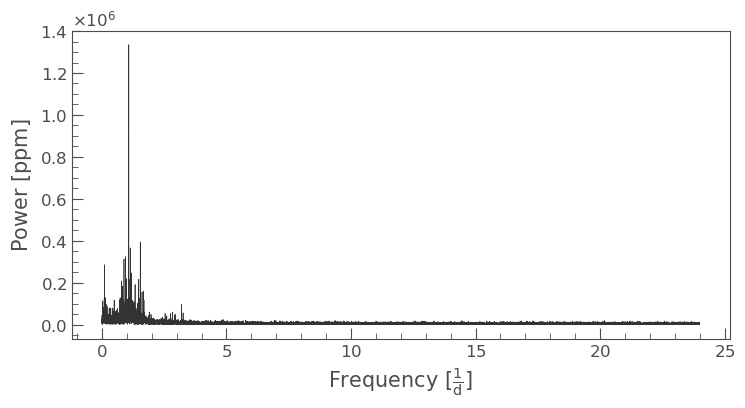

In [72]:
print(pg)
ax = pg.plot()
print(ax)


In [60]:
import pandas as pd
df = pd.read_csv("output.txt", sep="\s+", comment="#", names=["per", "ampl"])

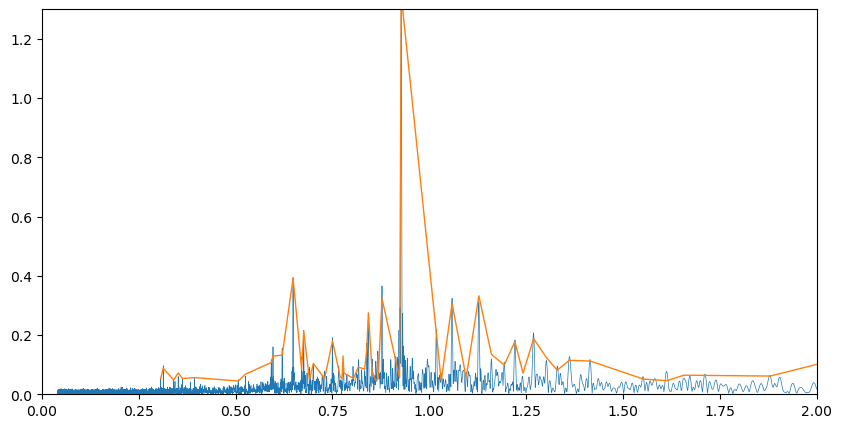

In [71]:
plt.figure(figsize=(10,5))
x = pg.period.value
y = pg.power.value
plt.plot(x,y*1e-6, linewidth=0.5)
#for p in df['per']:
    #plt.axvline(x=p, color='red', linestyle='--', linewidth=0.5)
plt.plot(df['per'], df['ampl']*1e3, linewidth=1)
plt.ylim(0,1.3)
plt.xlim(0,2)
plt.savefig('periodigram.pdf')
plt.show()

In [5]:
import pickle
import numpy as np

TIC = 177162802
sector = 3

picklefile = f'./spbstars/processed_spb1/tic{TIC}_sec{sector}_corrected.pickle'

with open(picklefile, "rb") as f:
    info = pickle.load(f)

In [19]:
from astropy.io import fits
from pathlib import Path

hduls = [fits.open(file) for file in Path ('./spbstars/spb1/').glob(f'tic{TIC}_sec*.fits')]

hduls[1].header


AttributeError: 'HDUList' object has no attribute 'header'

In [16]:
x = []
y = []
for hdul in hduls:
    x.append(hdul[0].header["TSTART"])
    y.append(hdul[1].header["NREADOUT"])

print(x)
print(y)

[1325.31384463669, 1569.438447235702, 1596.771766705971, 1624.959560765034, 1653.91788085582, 1354.104260423924, 2036.278810790905, 2061.848244977567, 2088.235892777647, 1382.041758553067, 2115.881721183574, 2144.513656838462, 2174.221705237373, 2201.728631822493, 2228.749449936955, 2254.986763380706, 2280.903421790272, 2307.236749206186, 2361.771740987993, 1410.916736046796, 1437.97895591723, 1468.270645495856, 2962.79414737702, 2988.435339659559, 3014.363563507535, 3041.108915320975, 3068.734219095357, 3097.669392132419, 3126.636968156304, 3154.606857189869, 3182.348658529432, 1491.624772912771, 1517.355138483324, 3663.034288710453, 3718.13266809158, 1543.230127374198, 3747.153500922879, 3829.852846006581, 3856.257925322622, 3882.327354628448, 3907.768236214334, 3933.652846328622]
[720, 720, 720, 720, 720, 720, 240, 240, 240, 720, 240, 240, 240, 240, 240, 240, 240, 240, 240, 720, 720, 720, 80, 80, 80, 80, 80, 80, 80, 80, 80, 720, 720, 80, 80, 720, 80, 80, 80, 80, 80, 80]


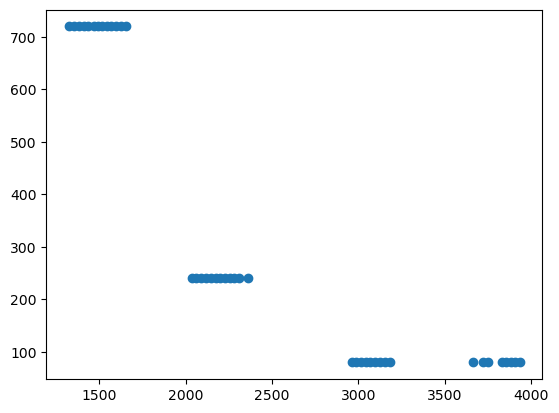

In [18]:
plt.scatter(x,y)

<ErrorbarContainer object of 3 artists>

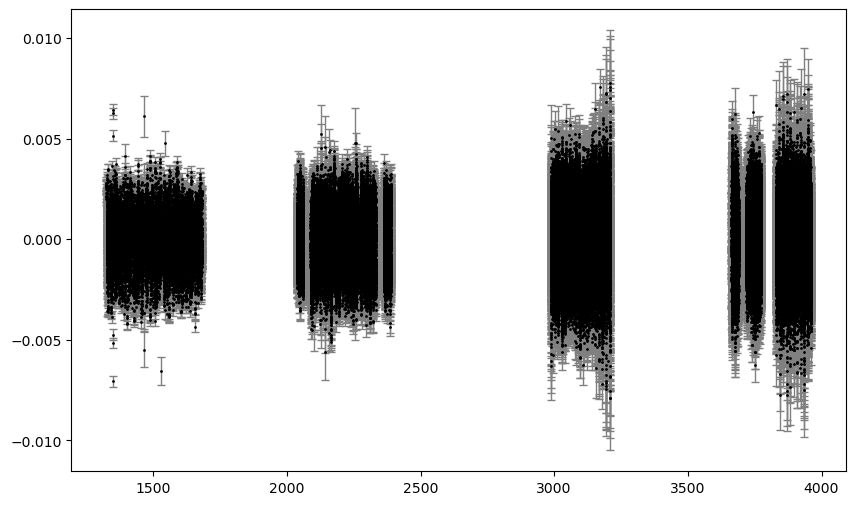

In [28]:
import pandas as pd

df = pd.read_csv('./spbstars/stitched_spb1/lc_tic177162802_corrected_stitched.csv')
plt.figure(figsize=(10,6))
plt.errorbar(
    df['time'],
    df['flux'],
    yerr=df['flux_err'],
    fmt='o',                # enkel markers (geen lijn)
    markersize=1,           # grootte van de punten
    ecolor='gray',          # kleur van de error bars
    elinewidth=1,           # dikte van de error bars
    capsize=3,              # kleine "hoedjes" op de error bars
    color='black',          # kleur van de punten
    linestyle='none'        # geen verbindingslijn
)